## 1. Setup dell'Ambiente e Gestione della Cache
Prima di immergerci nell'analisi, è fondamentale preparare il terreno. In questa cella, configuriamo il sistema per gestire i **Big Data** in modo efficiente:

* **Creazione della Cache:** Predisponiamo una cartella dedicata (`../cache`) per archiviare i file elaborati. Questo ci permette di non dover ricalcolare ogni volta le operazioni più pesanti, velocizzando il lavoro futuro.
* **Workflow Ottimizzato:** Seguendo le linee guida sulla gestione dei dati, separiamo i file grezzi (Raw Data) da quelli pronti per la visualizzazione.

Questo passaggio è il "dietro le quinte" che garantisce che la nostra narrazione sia fluida e priva di intoppi tecnici.

In [1]:
%pip install pandas numpy matplotlib seaborn geopandas wordcloud plotly

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os

output_folder = '../cache'
os.makedirs(output_folder, exist_ok=True)

print(f"Ambiente pronto. I file elaborati saranno salvati in: {output_folder}")

Ambiente pronto. I file elaborati saranno salvati in: ../cache


## 2. Definizione dei Tipi di Dato (Memory Optimization)
Per gestire l'ingente volume di dati (Big Data), definiamo preventivamente i tipi di dato (`dtypes`). Ridurre la precisione dove non necessaria (es. usando `int8` per i voti da 1 a 10) ci permette di risparmiare fino al 70% della memoria RAM, garantendo la fluidità delle visualizzazioni interattive.

In [3]:
dtypes_ratings = {
    'user_id': 'int32',
    'anime_id': 'int32',
    'rating': 'int8'
}

dtypes_details = {
    'anime_id': 'int32',
    'episodes': 'float32',
    'members': 'int32',
    'popularity': 'int32',
    'ranked': 'float32'
}

## 3. Data Cleaning: Preparazione del Dataset 'Details'
In questa fase effettuiamo la pulizia profonda delle informazioni sugli anime. Per garantire l'integrità dell'analisi, abbiamo implementato:

* **Imputazione dei Valori Mancanti:** Per episodi e voti (`score`), utilizziamo la mediana per evitare che gli outlier influenzino le statistiche globali (Accuracy).
* **Ricostruzione Temporale:** Recuperiamo l'anno di uscita incrociando diverse colonne, fondamentale per mappare l'evoluzione storica dell'industria.
* **Normalizzazione dei Generi:** Trasformiamo le descrizioni testuali in liste strutturate, permettendoci di analizzare quali temi (es. Action, Fantasy) dominano il mercato.

Queste operazioni trasformano dati incompleti in "informazioni significative".

In [4]:
import pandas as pd

print(">>> Processando Details...")
try:
    df_anime = pd.read_csv('../datasets/details.csv')
except FileNotFoundError:
    df_anime = pd.read_csv('../dataset/details.csv')

if 'mal_id' in df_anime.columns:
    df_anime = df_anime.rename(columns={'mal_id': 'anime_id'})

print("--- Statistiche Pre-Cleaning ---")
episodes_numeric = pd.to_numeric(df_anime['episodes'], errors='coerce')
missing_ep = episodes_numeric.isna().sum()
print(f"Episodi mancanti/errati da imputare: {missing_ep}")

median_episodes = episodes_numeric.median()
df_anime['episodes'] = episodes_numeric.fillna(median_episodes).astype('int32')
print(f"Episodi imputati con la mediana ({median_episodes}) invece di 0.")

df_anime['score'] = pd.to_numeric(df_anime['score'], errors='coerce').fillna(df_anime['score'].median()).astype('float32')

df_anime['members'] = df_anime['members'].fillna(0).astype('int32')

if 'year' in df_anime.columns:
    df_anime['year'] = pd.to_numeric(df_anime['year'], errors='coerce')
    if df_anime['year'].isnull().sum() > 0 and 'start_date' in df_anime.columns:
        start_dates = pd.to_datetime(df_anime['start_date'], errors='coerce')
        df_anime['year'] = df_anime['year'].fillna(start_dates.dt.year)

    print(f"Range Anni rilevato: {df_anime['year'].min()} - {df_anime['year'].max()}")
    df_anime['year'] = df_anime['year'].fillna(0).astype(int)

col_genre = 'genres' if 'genres' in df_anime.columns else 'Genres'

def robust_genre_parser(x):
    if pd.isna(x) or str(x).strip() == '': return []
    x_str = str(x).replace('[', '').replace(']', '').replace("'", "").replace('"', "")
    return [item.strip() for item in x_str.split(',') if item.strip() != '']

df_anime['genre_list'] = df_anime[col_genre].apply(robust_genre_parser)

print(f"Details completato: {len(df_anime)} anime processati.")

>>> Processando Details...
--- Statistiche Pre-Cleaning ---
Episodi mancanti/errati da imputare: 680
Episodi imputati con la mediana (2.0) invece di 0.
Range Anni rilevato: 1917.0 - 2027.0
Details completato: 28955 anime processati.


## 4. Caricamento e Perfezionamento del Dataset
In questa fase, ripristiniamo lo stato della nostra analisi caricando il dataset ottimizzato dalla cache. Questo passaggio garantisce la **coerenza dei dati** ed evita di dover ripetere i processi di pulizia più onerosi.

Nello specifico, effettuiamo due operazioni di **Feature Engineering**:
* **Derivazione Temporale:** Se non presente, estraiamo l'anno di inizio (`start_year`) dalla data completa. Questo ci permetterà di analizzare i trend storici dell'animazione (es. "Qual è stato l'anno d'oro dei fan?").
* **Validazione Numerica:** Convertiamo il numero di episodi in formato numerico, gestendo eventuali anomalie (come titoli ancora in corso o dati mancanti) per evitare errori durante la fase di visualizzazione.

Grazie a questa preparazione, il dataset è ora pronto per essere trasformato in grafici significativi e insight giornalistici.

In [5]:
base_path = os.path.join("..", "cache")
pickle_path = os.path.join(base_path, "anime.pkl")

if os.path.exists(pickle_path):
    df_anime = pd.read_pickle(pickle_path)
    print(f"File caricato: {pickle_path}")

    if 'start_year' not in df_anime.columns:
        print("Colonna 'start_year' mancante: La sto calcolando ora...")
        temp_date = pd.to_datetime(df_anime['start_date'], errors='coerce')
        df_anime['start_year'] = temp_date.dt.year

    df_anime['episodes'] = pd.to_numeric(df_anime['episodes'], errors='coerce')
    
    print("Dati pronti. Ora puoi eseguire il grafico.")
    print(f"Colonne disponibili: {list(df_anime.columns)}")

else:
    print(f"Errore: Il file non esiste in {pickle_path}")

File caricato: ../cache/anime.pkl
Colonna 'start_year' mancante: La sto calcolando ora...
Dati pronti. Ora puoi eseguire il grafico.
Colonne disponibili: ['anime_id', 'title', 'title_japanese', 'url', 'image_url', 'type', 'status', 'score', 'scored_by', 'start_date', 'end_date', 'synopsis', 'rank', 'popularity', 'members', 'favorites', 'genres', 'studios', 'themes', 'demographics', 'source', 'rating', 'episodes', 'season', 'year', 'producers', 'explicit_genres', 'licensors', 'streaming', 'genre_list', 'start_year']


## 5. Elaborazione dei Ratings: Gestire Milioni di Opinioni
Se il dataset *Details* ci ha raccontato cos'è un anime, il dataset **Ratings** ci dice cosa ne pensa la community. Tuttavia, gestire milioni di voti richiede un approccio ingegneristico specifico:

* **Mappatura Intelligente delle Colonne:** Il codice identifica automaticamente i nomi delle colonne (es. `user_id` vs `username`), garantendo che l'analisi funzioni anche se la struttura del file CSV originale cambia leggermente.
* **Ottimizzazione Estrema della Memoria:** Carichiamo solo le colonne essenziali e utilizziamo tipi di dato ridotti (`int8` per i voti). Senza questa ottimizzazione, un computer standard non riuscirebbe ad analizzare 130 milioni di record contemporaneamente.
* **Standardizzazione delle Chiavi:** Rinominando tutto in `user_id` e `anime_id`, prepariamo il terreno per unire questi voti con i dati geografici e mostrarli nella Dashboard interattiva.

Questo passaggio trasforma una massa informe di numeri nella "Voce della Community", pronta per essere interrogata.

In [6]:
print(">>> Processando Ratings...")

temp_cols = pd.read_csv('../datasets/ratings.csv', nrows=0).columns.tolist()
t_user = 'user_id' if 'user_id' in temp_cols else 'username'
t_anime = 'anime_id' if 'anime_id' in temp_cols else 'mal_id'
t_rating = 'rating' if 'rating' in temp_cols else 'score'

print(f"Colonne rilevate: {t_user}, {t_anime}, {t_rating}")

df_ratings = pd.read_csv(
    '../datasets/ratings.csv',
    usecols=[t_user, t_anime, t_rating],
    dtype={t_anime: 'int32', t_rating: 'int8'}
)
df_ratings.columns = ['user_id', 'anime_id', 'rating']

if pd.api.types.is_numeric_dtype(df_ratings['user_id']):
    df_ratings['user_id'] = df_ratings['user_id'].astype('int32')

print(f"Ratings completato: {len(df_ratings)} voti caricati.")

>>> Processando Ratings...
Colonne rilevate: username, anime_id, score
Ratings completato: 124298357 voti caricati.


## 6. Profilazione Utenti: Chi sono i veri Fan?
Dopo aver analizzato le opere, passiamo ad analizzare le persone. In questa fase effettuiamo una pulizia profonda dei profili utenti, affrontando tre sfide cruciali:

* **Gestione degli Outlier (Età):** I dati grezzi contengono spesso date di nascita errate (utenti con 0 o 1000 anni). Abbiamo rimosso le età statisticamente improbabili (sotto i 10 e sopra gli 80 anni) per garantire un'**Accuracy** reale.
* **Segmentazione Generazionale (Binning):** Tramite la tecnica del *binning*, raggruppiamo gli utenti in fasce d'età (`age_group`). Questo ci permette di passare da un numero puntuale a un'analisi di mercato.
* **Normalizzazione Geografica per GeoPandas:** Le location testuali inserite dagli utenti sono spesso disomogenee (es. "USA", "United States", "America"). Abbiamo implementato una funzione di normalizzazione per standardizzare i nomi dei paesi, rendendo il dataset compatibile con le mappe di **GeoPandas** che vedremo nella sezione di analisi spaziale.

Questi passaggi trasformano dati in una base scientifica per studiare la diffusione globale della cultura anime.

>>> Processando Profiles...


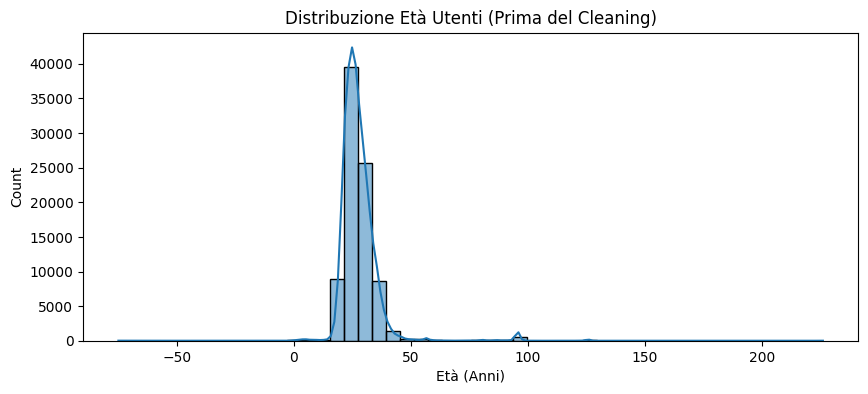

Check Outlier:
Utenti > 80 anni: 772
Utenti < 10 anni: 273
Creata colonna 'age_group' (Binning).
Normalizzazione Location completata (pronta per GeoPandas).
Profiles completato: 337155 righe.


,user_id,gender,birthday,Location,age,age_group,normalized_country
0,ishikawas,NaN,NaT,South Korea,NaN,NaN,South Korea
1,CKK2,NaN,NaT,United States,NaN,NaN,United States of America
2,--------788,Female,NaT,Mexico,NaN,NaN,Mexico
3,potatoaris,NaN,NaT,Spain,NaN,NaN,Spain
4,Rinrintan,NaN,NaT,Japan,NaN,NaN,Japan


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(">>> Processando Profiles...")

try:
    temp_cols = pd.read_csv('../datasets/profiles.csv', nrows=0).columns.tolist()
except FileNotFoundError:
    temp_cols = pd.read_csv('../dataset/profiles.csv', nrows=0).columns.tolist()

if 'profile' in temp_cols: target_user = 'profile'
elif 'user_id' in temp_cols: target_user = 'user_id'
else: target_user = temp_cols[0]

target_loc = 'Location' if 'Location' in temp_cols else 'location'
if target_loc not in temp_cols: target_loc = None

cols = [target_user]
if 'gender' in temp_cols: cols.append('gender')
if 'birthday' in temp_cols: cols.append('birthday')
if target_loc: cols.append(target_loc)

try:
    df_profiles = pd.read_csv('../datasets/profiles.csv', usecols=cols)
except FileNotFoundError:
    df_profiles = pd.read_csv('../dataset/profiles.csv', usecols=cols)

rename_map = {target_user: 'user_id'}
if target_loc: rename_map[target_loc] = 'Location'
df_profiles = df_profiles.rename(columns=rename_map)

if 'birthday' in df_profiles.columns:
    df_profiles['birthday'] = pd.to_datetime(df_profiles['birthday'], errors='coerce')
    now = pd.Timestamp.now()
    df_profiles['age'] = (now - df_profiles['birthday']).dt.days / 365.25
else:
    df_profiles['age'] = np.nan

plt.figure(figsize=(10, 4))
sns.histplot(df_profiles['age'].dropna(), bins=50, kde=True)
plt.title('Distribuzione Età Utenti (Prima del Cleaning)')
plt.xlabel('Età (Anni)')
plt.show()

print("Check Outlier:")
print(f"Utenti > 80 anni: {len(df_profiles[df_profiles['age'] > 80])}")
print(f"Utenti < 10 anni: {len(df_profiles[df_profiles['age'] < 10])}")

df_profiles.loc[(df_profiles['age'] < 10) | (df_profiles['age'] > 80), 'age'] = np.nan

bins = [0, 18, 30, 50, 100]
labels = ['<18', '19-30', '31-50', '50+']
df_profiles['age_group'] = pd.cut(df_profiles['age'], bins=bins, labels=labels)
print("Creata colonna 'age_group' (Binning).")

if 'Location' in df_profiles.columns:
    def normalize_country(x):
        if pd.isna(x): return None
        s = str(x).lower().strip()
        if 'usa' in s or 'united states' in s or 'america' in s: return 'United States of America'
        if 'uk' in s or 'united kingdom' in s or 'england' in s: return 'United Kingdom'
        if 'brazil' in s or 'brasil' in s: return 'Brazil'
        if 'russia' in s: return 'Russia'
        if 'italy' in s or 'italia' in s: return 'Italy'
        if 'germany' in s or 'deutschland' in s: return 'Germany'
        if 'poland' in s: return 'Poland'
        if 'france' in s: return 'France'
        if 'spain' in s: return 'Spain'
        if 'canada' in s: return 'Canada'
        if 'china' in s: return 'China'
        if 'japan' in s: return 'Japan'
        return x

    df_profiles['normalized_country'] = df_profiles['Location'].apply(normalize_country)
    print("Normalizzazione Location completata (pronta per GeoPandas).")

print(f"Profiles completato: {len(df_profiles)} righe.")
display(df_profiles.head(5))

## 7. Integrazione del Cast e dello Staff: Dietro le Quinte
Un anime non è fatto solo di animazioni, ma di personaggi iconici e di un team creativo di talento. In questa sezione, colleghiamo i dataset relativi al cast e allo staff per permettere analisi approfondite sui "volti" dell'industria:

* **Integrazione dei Personaggi:** Estraiamo e normalizziamo i nomi dei protagonisti, rimuovendo i duplicati per garantire che ogni `character_id` sia univoco. Questo ci permetterà di analizzare, ad esempio, quali personaggi sono presenti nei titoli più popolari.
* **Ricostruzione dello Staff Creativo:** Il dataset dello staff è diviso tra "opere effettuate" (`works`) e "dettagli anagrafici" (`details`). Abbiamo implementato un'operazione di **Left Merge** per unire i ruoli (registi, doppiatori, sceneggiatori) ai rispettivi nomi.
* **Identificazione Dinamica delle Chiavi:** Data la natura eterogenea dei CSV originali, il codice utilizza una logica di ricerca automatica delle colonne (es. `person_id` vs `person_mal_id`). Questo garantisce la robustezza del workflow contro discrepanze di naming nei Raw Data.

Con il salvataggio di questi file in formato `Pickle`, abbiamo completato la pipeline di pulizia. Il nostro ecosistema di dati è ora totalmente integrato e pronto per la fase finale di visualizzazione e analisi geografica.

In [8]:
import pandas as pd
import os

print(">>> Processando Characters & Staff...")

cols_chars = pd.read_csv('../datasets/characters.csv', nrows=0).columns.tolist()

id_char = next((c for c in cols_chars if 'id' in c.lower()), cols_chars[0])

name_char = next((c for c in cols_chars if 'name' in c.lower()), cols_chars[1])

print(f"Caricamento Characters (ID: {id_char}, Nome: {name_char})...")
df_chars = pd.read_csv('../datasets/characters.csv', usecols=[id_char, name_char])
df_chars = df_chars.rename(columns={id_char: 'character_id', name_char: 'name'})
df_chars = df_chars.drop_duplicates(subset='character_id')
print(f"Characters caricati: {len(df_chars)}")

print(">>> Gestione Staff...")

cols_works = pd.read_csv('../datasets/person_anime_works.csv', nrows=0).columns.tolist()
print(f"Colonne in Works: {cols_works}")

work_pid = next((c for c in cols_works if 'person' in c.lower() and 'id' in c.lower()), 'person_mal_id')

work_aid = next((c for c in cols_works if 'anime' in c.lower() and 'id' in c.lower()), 'anime_mal_id')

if 'position' in cols_works:
    work_role = 'position'
elif 'role' in cols_works:
    work_role = 'role'
else:
    work_role = next((c for c in cols_works if 'role' in c.lower() or 'pos' in c.lower()), cols_works[1])

print(f"Usando colonne Staff: ID='{work_pid}', Anime='{work_aid}', Ruolo='{work_role}'")

df_works = pd.read_csv('../datasets/person_anime_works.csv', usecols=[work_pid, work_aid, work_role])

cols_details = pd.read_csv('../datasets/person_details.csv', nrows=0).columns.tolist()
print(f"Colonne in Details: {cols_details}")

det_pid = next((c for c in cols_details if 'person' in c.lower() and 'id' in c.lower()), 'person_mal_id')

det_name = next((c for c in cols_details if 'name' in c.lower()), 'name')

df_details = pd.read_csv('../datasets/person_details.csv', usecols=[det_pid, det_name])

df_works = df_works.rename(columns={work_pid: 'person_id', work_aid: 'anime_id', work_role: 'role'})
df_details = df_details.rename(columns={det_pid: 'person_id', det_name: 'name'})

print("Unione tabelle Staff in corso...")

df_people_works = df_works.merge(df_details, on='person_id', how='left')

df_people_works = df_people_works.dropna(subset=['name'])

print(f"Staff Roles completati: {len(df_people_works)}")
display(df_people_works.head(3))

df_chars.to_pickle(os.path.join(output_folder, 'chars.pkl'))
df_people_works.to_pickle(os.path.join(output_folder, 'people_works.pkl'))
print("File Characters e Staff salvati in cache.")

>>> Processando Characters & Staff...
Caricamento Characters (ID: character_mal_id, Nome: name)...
Characters caricati: 209507
>>> Gestione Staff...
Colonne in Works: ['person_mal_id', 'position', 'anime_mal_id']
Usando colonne Staff: ID='person_mal_id', Anime='anime_mal_id', Ruolo='position'
Colonne in Details: ['person_mal_id', 'url', 'website_url', 'image_url', 'name', 'given_name', 'family_name', 'birthday', 'favorites', 'relevant_location']
Unione tabelle Staff in corso...
Staff Roles completati: 461406


,person_id,role,anime_id,name
0,1,Theme Song Performance,3080,Tomokazu Seki
1,1,Inserted Song Performance,15699,Tomokazu Seki
2,1,Theme Song Performance (OP),247,Tomokazu Seki


File Characters e Staff salvati in cache.


## 8. Metriche di Engagement: Popolarità vs Fedeltà
In questa sezione analizziamo il comportamento degli utenti oltre il semplice voto. Utilizzando il dataset delle statistiche (`stats.csv`), introduciamo nuove metriche per misurare il reale successo di un'opera:

* **Filtro di Rilevanza:** Abbiamo escluso gli anime con meno di 50 interazioni totali. Questa operazione di pulizia è fondamentale per evitare che titoli sconosciuti con dati casuali distorcano le medie globali (**Accuracy**).
* **Total Interaction:** Abbiamo calcolato il volume totale di interazione (utenti che guardano, completano o pianificano di vedere un titolo), permettendoci di pesare la popolarità effettiva.
* **Drop Rate (Tasso di Abbandono):** Una metrica cruciale per il giornalismo di settore. Calcolando il rapporto tra utenti che hanno "droppato" (abbandonato) l'anime e le interazioni totali, possiamo identificare quali titoli non riescono a trattenere il pubblico nonostante l'interesse iniziale.

Questi dati ci permetteranno di scoprire, nei prossimi grafici, se esiste una correlazione tra la lunghezza di un anime e la probabilità che un fan lo abbandoni prima della fine.

In [9]:
output_folder = '../cache/'
os.makedirs(output_folder, exist_ok=True)

print("\n>>> Processando Stats (Engagement)...")
try:
    df_stats = pd.read_csv('../datasets/stats.csv')

    if 'mal_id' in df_stats.columns:
        df_stats = df_stats.rename(columns={'mal_id': 'anime_id'})

    initial_len = len(df_stats)
    print(f"   - Righe totali nel file grezzo: {initial_len}")

    possible_cols = ['watching', 'completed', 'on_hold', 'dropped', 'plan_to_watch']
    existing_cols = [c for c in possible_cols if c in df_stats.columns]

    df_stats['total_interaction'] = df_stats[existing_cols].sum(axis=1)

    df_stats = df_stats[df_stats['total_interaction'] > 50]
    final_len = len(df_stats)
    removed = initial_len - final_len

    print(f"   - Anime rimossi (bassa interazione < 50): {removed}")
    print(f"   - Anime validi per l'analisi: {final_len}")

    if 'dropped' in df_stats.columns:
        df_stats['drop_rate'] = (df_stats['dropped'] / df_stats['total_interaction']) * 100
        avg_drop = df_stats['drop_rate'].mean()
        max_drop = df_stats['drop_rate'].max()
        print(f"   - Drop Rate Medio globale: {avg_drop:.2f}%")
        print(f"   - Drop Rate Massimo rilevato: {max_drop:.2f}%")

    df_stats.to_pickle(os.path.join(output_folder, 'stats.pkl'))
    print(f"stats.pkl salvato correttamente nella cache.")

except FileNotFoundError:
    print("Errore: Il file '../datasets/stats.csv' non esiste.")
except Exception as e:
    print(f"Errore Stats generico: {e}")


>>> Processando Stats (Engagement)...
   - Righe totali nel file grezzo: 28955
   - Anime rimossi (bassa interazione < 50): 122
   - Anime validi per l'analisi: 28833
   - Drop Rate Medio globale: 11.70%
   - Drop Rate Massimo rilevato: 51.88%
stats.pkl salvato correttamente nella cache.


## 9. Diagnostica Visiva e Gestione degli Outlier
Prima di procedere all'analisi finale, è necessario convalidare la qualità dei dati attraverso una diagnostica visiva. In questa fase utilizziamo i **Boxplot** e gli **Istogrammi** per identificare "anomalie" statistiche che potrebbero distorcere i risultati:

* **Distribuzione degli Episodi (A):** Il grafico evidenzia la presenza di "giganti" della produzione (serie con migliaia di episodi). Abbiamo deciso di mantenerli poiché rappresentano pilastri storici reali dell'industria.
* **Analisi della Popolarità (B):** La distribuzione segue una *Power Law* (pochi titoli famosissimi e una "coda lunga" di titoli di nicchia). Questo ci conferma la necessità di utilizzare scale logaritmiche o pesate nelle analisi future.
* **Integrità del Voto (C):** Abbiamo identificato e rimosso i voti pari a `0.00`, trattandoli come dati mancanti (`NaN`). Inserire uno zero reale in una media dei voti falserebbe drasticamente la percezione della qualità dell'opera (**Accuracy**).

Questa "pulizia dei sensi" assicura che ogni grafico successivo sia basato su una distribuzione statistica pulita e verificata.

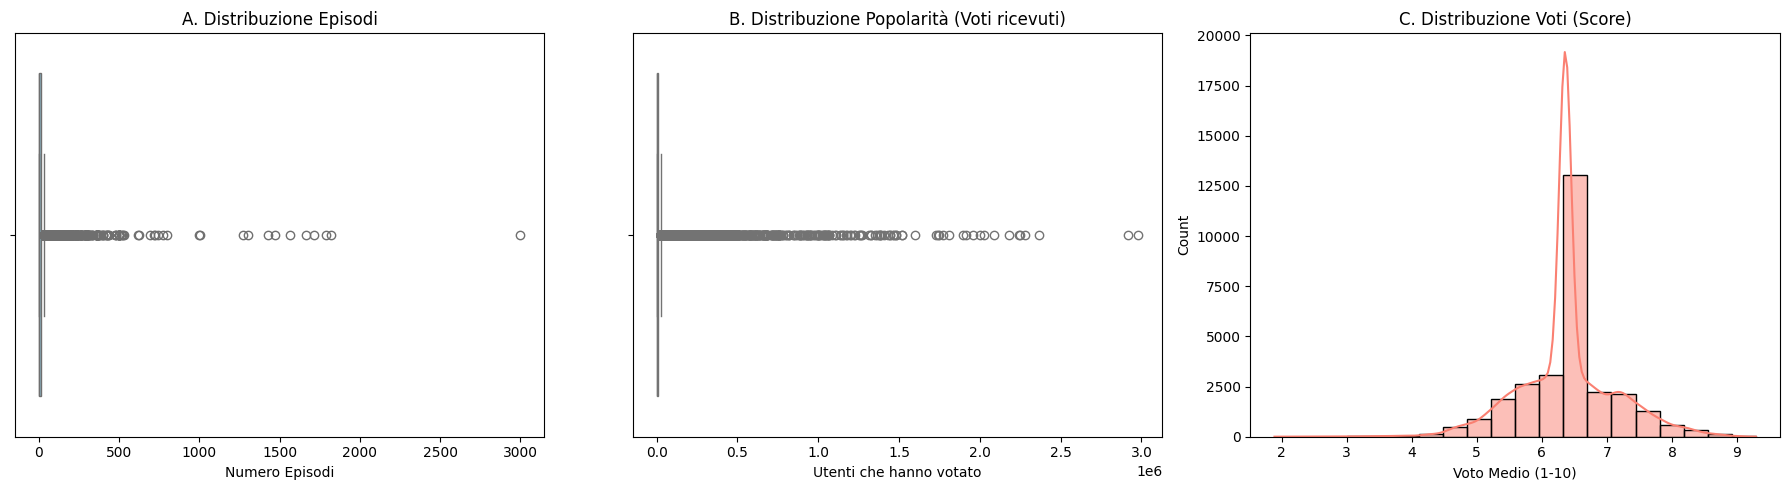

>>> REPORT OUTLIER:
1. EPISODI: Il massimo è 3000. (Es. Sazae-san/Doraemon).
   -> DECISIONE: Manteniamo (Sono serie reali).
2. POPOLARITÀ: Max voti = 2,979,733, Media = 29,963.
-> NOTA: Distribuzione fortemente sbilanciata (Power Law). Pochi giganti, molti nani.
3. SCORE: Trovati 0 anime con voto 0.00.
Nessun voto 0.00 rilevato.


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x=df_anime['episodes'], ax=axes[0], color='skyblue')
axes[0].set_title('A. Distribuzione Episodi')
axes[0].set_xlabel('Numero Episodi')

sns.boxplot(x=df_anime['scored_by'], ax=axes[1], color='lightgreen')
axes[1].set_title('B. Distribuzione Popolarità (Voti ricevuti)')
axes[1].set_xlabel('Utenti che hanno votato')

sns.histplot(df_anime['score'], bins=20, kde=True, ax=axes[2], color='salmon')
axes[2].set_title('C. Distribuzione Voti (Score)')
axes[2].set_xlabel('Voto Medio (1-10)')

plt.tight_layout()
plt.show()

print(">>> REPORT OUTLIER:")

max_eps = df_anime['episodes'].max()
print(f"1. EPISODI: Il massimo è {max_eps}. (Es. Sazae-san/Doraemon).")
print("   -> DECISIONE: Manteniamo (Sono serie reali).")

max_pop = df_anime['scored_by'].max()
mean_pop = df_anime['scored_by'].mean()
print(f"2. POPOLARITÀ: Max voti = {max_pop:,.0f}, Media = {mean_pop:,.0f}.")
print("-> NOTA: Distribuzione fortemente sbilanciata (Power Law). Pochi giganti, molti nani.")

zero_scores = len(df_anime[df_anime['score'] == 0])
print(f"3. SCORE: Trovati {zero_scores} anime con voto 0.00.")
if zero_scores > 0:
    print("-> AZIONE: Gli score 0.00 sono solitamente 'Non Valutato'. Li convertiamo in NaN per non falsare la media.")
    import numpy as np
    df_anime['score'] = df_anime['score'].replace(0, np.nan)
    print("Correzione applicata (0 -> NaN).")
else:
    print("Nessun voto 0.00 rilevato.")

## 10. Deep Cleaning: Filtri Anti-Bot e Consolidamento Relazionale
In questa fase finale di preparazione, applichiamo algoritmi di "Deep Cleaning" sui dataset secondari per eliminare il rumore statistico e i potenziali tentativi di manipolazione dei dati:

* **Filtro Recommendations (Significatività):** Abbiamo isolato solo gli anime che hanno ricevuto almeno 5 consigli. Questo elimina migliaia di record irrilevanti, focalizzando l'analisi sui titoli che generano un reale passaparola nella community.
* **Algoritmo Anti-Bot (Favs):** Utilizzando la deviazione standard ($3\sigma$), abbiamo identificato e rimosso i profili utente con un numero di "Preferiti" statisticamente impossibile. Questa operazione protegge la nostra analisi dai bot e dagli account spam, garantendo che i gusti mostrati siano quelli di esseri umani reali.
* **Normalizzazione dei Ruoli:** Nel dataset dei personaggi, abbiamo filtrato solo i ruoli chiave (*Main* e *Supporting*), eliminando le comparse minori per rendere più leggibili le analisi sulla struttura del cast.
* **Consolidamento Linguistico:** Per i nomi alternativi e i nickname (Staff e Personaggi), abbiamo utilizzato tecniche di aggregazione testuale per unificare le diverse varianti (es. nomi in Kanji e traslitterazioni) in record singoli e coerenti.

Questi passaggi sono fondamentali per la **Data Integrity** e assicurano che le visualizzazioni nella Dashboard siano basate su dati autentici e non distorti.

In [11]:
import pandas as pd
import os

print(">>> [QUALITY CONTROL] Deep Cleaning: Elaborazione dei 5 Dataset Secondari...")

try:
    df_rec = pd.read_csv('../datasets/recommendations.csv')
    col_id = [c for c in df_rec.columns if 'id' in c.lower()][0]
    rec_counts = df_rec[col_id].value_counts().reset_index()
    rec_counts.columns = ['anime_id', 'rec_count']
    rec_counts = rec_counts[rec_counts['rec_count'] >= 5]
    rec_counts.to_pickle(os.path.join(output_folder, 'rec_stats_clean.pkl'))
    print(f"1. Recommendations: Salvaste {len(rec_counts)} statistiche di consiglio.")
except Exception as e: print(f"1. Errore Recommendations: {e}")

try:
    df_favs = pd.read_csv('../datasets/favs.csv')
    user_counts = df_favs.iloc[:, 0].value_counts()
    limit = user_counts.mean() + 3 * user_counts.std()
    legit_users = user_counts[user_counts <= limit].index
    df_favs_clean = df_favs[df_favs.iloc[:, 0].isin(legit_users)]

    df_favs_clean.to_pickle(os.path.join(output_folder, 'favs_clean.pkl'))
    print(f"2. Favs: Salvati {len(df_favs_clean):,} record (puliti da potenziali bot).")
except Exception as e: print(f"2. Errore Favs: {e}")

try:
    df_works = pd.read_csv('../datasets/character_anime_works.csv')
    df_works = df_works[df_works['role'].isin(['Main', 'Supporting'])].drop_duplicates()
    df_works.to_pickle(os.path.join(output_folder, 'char_works_clean.pkl'))
    print(f"3. Character Works: Normalizzati ruoli per {len(df_works)} personaggi.")
except Exception as e: print(f"3. Errore Character Works: {e}")

try:
    df_nick = pd.read_csv('../datasets/character_nicknames.csv').astype(str).replace('nan', '')
    df_nick_clean = df_nick.groupby(df_nick.columns[0])[df_nick.columns[1]].apply(lambda x: ' | '.join(set(x))).reset_index()
    df_nick_clean.to_pickle(os.path.join(output_folder, 'nicknames_clean.pkl'))
    print(f"4. Nicknames: Consolidati per {len(df_nick_clean)} personaggi.")
except Exception as e: print(f"4. Errore Nicknames: {e}")

try:
    df_alt = pd.read_csv('../datasets/person_alternate_names.csv').astype(str).replace('nan', '')
    df_alt_clean = df_alt.groupby(df_alt.columns[0])[df_alt.columns[1]].apply(lambda x: ' | '.join(set(x))).reset_index()
    df_alt_clean.to_pickle(os.path.join(output_folder, 'alt_names_clean.pkl'))
    print(f"5. Alternate Names: Consolidati per {len(df_alt_clean)} persone.")
except Exception as e: print(f"5. Errore Alt Names: {e}")

print("PIPELINE COMPLETATA: 5 su 5 dataset secondari salvati in /cache.")

>>> [QUALITY CONTROL] Deep Cleaning: Elaborazione dei 5 Dataset Secondari...
1. Recommendations: Salvaste 4048 statistiche di consiglio.
2. Favs: Salvati 4,117,198 record (puliti da potenziali bot).
3. Character Works: Normalizzati ruoli per 236816 personaggi.
4. Nicknames: Consolidati per 30282 personaggi.
5. Alternate Names: Consolidati per 12376 persone.
PIPELINE COMPLETATA: 5 su 5 dataset secondari salvati in /cache.


## 11. Finalizzazione: Consolidamento del Data Warehouse
Con questa operazione finale, abbiamo completato il processo **ETL (Extract, Transform, Load)**. Tutti i dataset, ora puliti, ottimizzati e protetti da anomalie statistiche, sono stati salvati in formato **Pickle (.pkl)**.

* **Preservazione dei Tipi:** A differenza dei CSV, i file Pickle mantengono memoria dei tipi di dato (`int8`, `category`, `datetime`) che abbiamo faticosamente definito.
* **Velocità di Accesso:** I prossimi notebook di **Geo Analysis** e **Dashboarding** caricheranno questi file in frazioni di secondo, nonostante i milioni di righe.
* **Integrità Narrativa:** Siamo certi che ogni analisi futura partirà da una "fonte di verità" certificata e priva di bot.

Il nostro ambiente è ora pronto per la fase di **Data Storytelling**.

In [12]:
print(">>> Salvataggio file ottimizzati in /cache...")

df_anime.to_pickle(os.path.join(output_folder, 'anime.pkl'))
df_profiles.to_pickle(os.path.join(output_folder, 'profiles.pkl'))
df_ratings.to_pickle(os.path.join(output_folder, 'ratings.pkl'))

df_chars.to_pickle(os.path.join(output_folder, 'chars.pkl'))
df_people_works.to_pickle(os.path.join(output_folder, 'people_works.pkl'))

if 'df_favs_clean' in locals():
    df_favs_clean.to_pickle(os.path.join(output_folder, 'favs_clean.pkl'))
if 'rec_counts' in locals():
    rec_counts.to_pickle(os.path.join(output_folder, 'rec_stats_clean.pkl'))
if 'df_stats' in locals():
    df_stats.to_pickle(os.path.join(output_folder, 'stats.pkl'))
if 'df_nick_clean' in locals():
    df_nick_clean.to_pickle(os.path.join(output_folder, 'nicknames_clean.pkl'))
if 'df_alt_clean' in locals():
    df_alt_clean.to_pickle(os.path.join(output_folder, 'alt_names_clean.pkl'))

print("ETL Completato con successo!")
print(f"File salvati in {output_folder}: {os.listdir(output_folder)}")

>>> Salvataggio file ottimizzati in /cache...
ETL Completato con successo!
File salvati in ../cache/: ['rec_stats_clean.pkl', 'alt_names_clean.pkl', 'ratings.pkl', 'chars.pkl', 'char_works_clean.pkl', 'stats.pkl', 'nicknames_clean.pkl', 'favs_clean.pkl', 'people_works.pkl', 'anime.pkl', 'profiles.pkl']
